In [2]:
import subprocess
subprocess.run(['pip','install','yfinance','pandas','matplotlib','seaborn'],
               capture_output=True)

print

<function print(*args, sep=' ', end='\n', file=None, flush=False)>

In [1]:
import yfinance as yf
import pandas as pd

tickers = ['TD.TO','RY.TO','BMO.TO','BNS.TO','CM.TO','NA.To']
data = yf.download(tickers, start='2022-01-01',end='2024-12-31')
print(data.shape)
print(data.columns.get_level_values(0).unique())
data['Close'].head()

[*********************100%***********************]  6 of 6 completed

(751, 30)
Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='object', name='Price')


Ticker,BMO.TO,BNS.TO,CM.TO,NA.TO,RY.TO,TD.TO
Date,,,,,,
2022-01-04,115.793541,70.977966,60.689156,84.554398,115.959702,81.503204
2022-01-05,114.890617,70.493584,61.455746,83.796562,117.213913,81.995392
2022-01-06,116.417366,71.290474,62.753628,83.609230,118.476501,82.495819
2022-01-07,117.468002,71.477966,63.625660,84.937576,120.120483,82.884834
2022-01-10,117.418762,71.040466,63.702732,84.111610,120.781471,82.545502


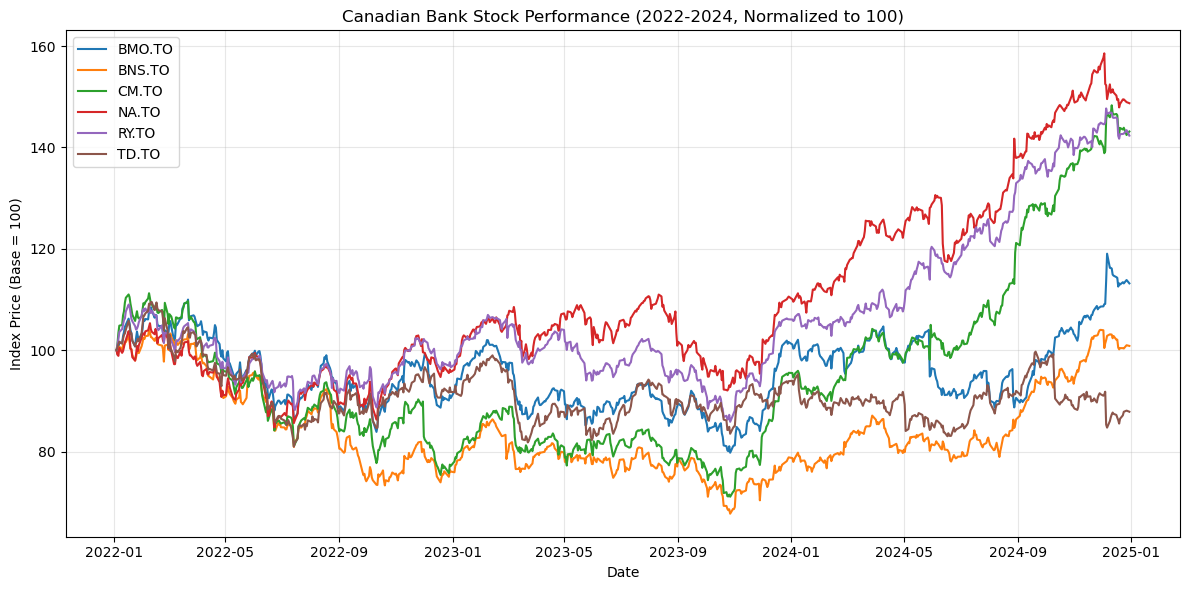

In [2]:
import matplotlib.pyplot as plt
#only get close price
close = data['Close']
# normalized:每家银行从100 开始（2022.01.04）看涨跌,Relative Performance Index
normalized = (close / close.iloc[0])*100
plt.figure(figsize=(12,6))
for ticker in normalized.columns:
    plt.plot(normalized.index,normalized[ticker],label=ticker)


plt.title('Canadian Bank Stock Performance (2022-2024, Normalized to 100)')
plt.xlabel('Date')
plt.ylabel('Index Price (Base = 100)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('bank_performance.png', dpi=150)
plt.show()



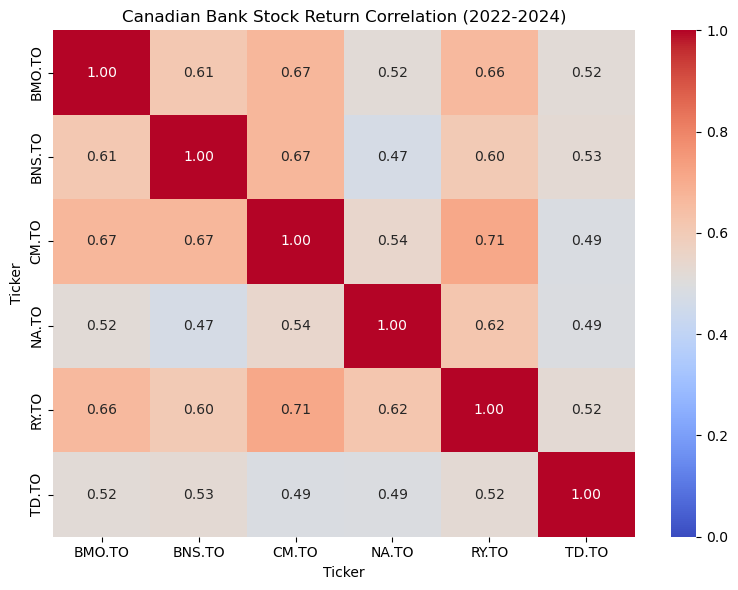

In [3]:
import seaborn as sns
#计算收盘价的日收益率
returns = close.pct_change().dropna()
#计算相关性矩阵
corr_matrix = returns.corr()
#hotspot 
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix,
            annot=True,       #显示数字
            fmt='.2f',        #保留两位小数
            cmap='coolwarm',  # 颜色 ：蓝=底相关，红=高相关
            vmin=0,vmax=1)


plt.title('Canadian Bank Stock Return Correlation (2022-2024)')
plt.tight_layout()
plt.savefig('correlation_matrix.png',dpi=150)
plt.show()

In [4]:
import numpy as np
# annual return volatility
annual_vol=returns.std()*np.sqrt(252)*100
print('Annual return')
print(annual_vol.round(2).sort_values(ascending=False))

#Beta: TSX Composite
tsx = yf.download('^GSPTSE', start='2022-01-01', end='2024-12-31')['Close']
tsx_returns = tsx.pct_change().dropna()
# Beta
print("\n=== Beta (relate to TSX) ===")
betas = {}
for ticker in returns.columns:
    aligned = pd.concat([returns[ticker], tsx_returns], axis=1).dropna()
    aligned.columns = ['bank','tsx']

    #Beta = Cov(bank,tsx)/Var(tsx)
    cov = aligned.cov().iloc[0,1]
    var = aligned['tsx'].var()
    betas[ticker] = round(cov / var, 3)

beta_df = pd.Series(betas).sort_values(ascending=False)
print(beta_df)

Annual return
Ticker
CM.TO     19.14
BMO.TO    18.71
TD.TO     17.95
NA.TO     17.77
BNS.TO    17.21
RY.TO     14.95
dtype: float64


[*********************100%***********************]  1 of 1 completed


=== Beta (relate to TSX) ===
BMO.TO    1.023
CM.TO     0.961
BNS.TO    0.852
TD.TO     0.849
NA.TO     0.832
RY.TO     0.815
dtype: float64


In [5]:
import pandas as pd
df = pd.read_excel(r'C:\Users\lenovo\Desktop\financials.xlsx')
print(df)
print('\n数据类型：')
print(df.dtypes)

df[['ROE', 'NIM', 'CET1', 'PCL_ratio']] = df[['ROE', 'NIM', 'CET1', 'PCL_ratio']] * 100
print(df.round(2))


      Bank  Year    ROE     NIM   CET1  PCL_ratio
0    RY.TO  2022  0.164  0.0148  0.126     0.0006
1    RY.TO  2023  0.142  0.0150  0.145     0.0029
2    RY.TO  2024  0.155  0.0154  0.132     0.0035
3    TD.TO  2022  0.180  0.0169  0.162     0.0014
4    TD.TO  2023  0.101  0.0174  0.144     0.0034
5    TD.TO  2024  0.082  0.0172  0.131     0.0046
6   BMO.TO  2022  0.229  0.0162  0.167     0.0006
7   BMO.TO  2023  0.060  0.0163  0.125     0.0035
8   BMO.TO  2024  0.097  0.0157  0.136     0.0057
9    CM.TO  2022  0.140  0.0140  0.117     0.0110
10   CM.TO  2023  0.103  0.0149  0.124     0.0200
11   CM.TO  2024  0.134  0.0147  0.133     0.0200
12  BNS.TO  2022  0.148  0.0220  0.115     0.0019
13  BNS.TO  2023  0.103  0.0212  0.130     0.0044
14  BNS.TO  2024  0.102  0.0216  0.131     0.0053
15   NA.TO  2022  0.188     NaN  0.127     0.0007
16   NA.TO  2023  0.163     NaN  0.135     0.0018
17   NA.TO  2024  0.172     NaN  0.137     0.0023

数据类型：
Bank          object
Year           int64
R

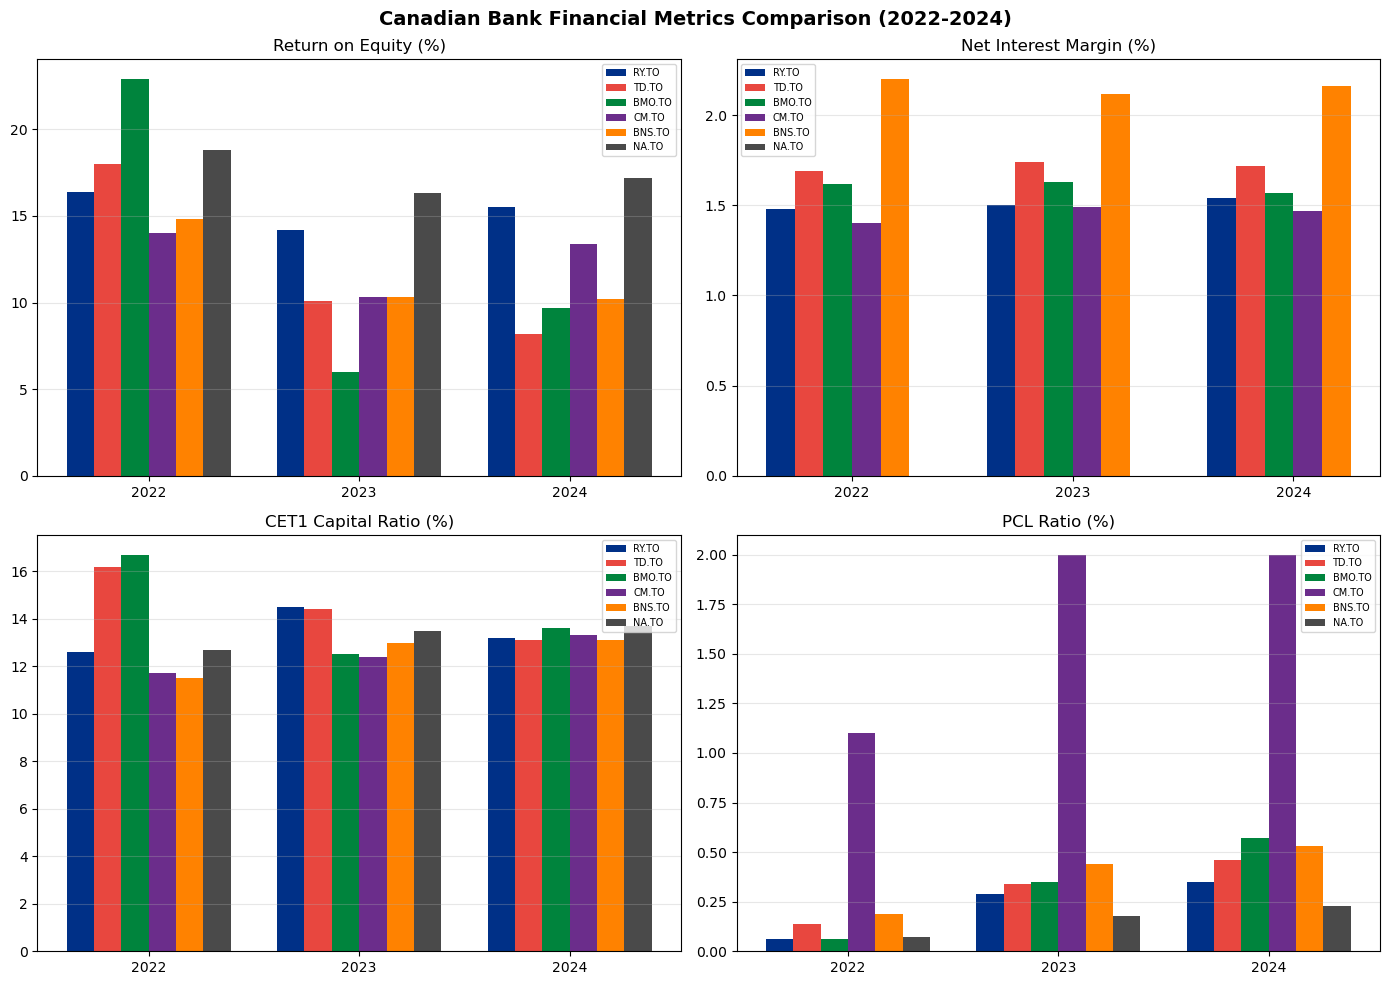

In [6]:
import matplotlib.pyplot as plt
import numpy as np

banks = df['Bank'].unique()
metrics = {'ROE': 'Return on Equity (%)', 
           'NIM': 'Net Interest Margin (%)', 
           'CET1': 'CET1 Capital Ratio (%)', 
           'PCL_ratio': 'PCL Ratio (%)'}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

colors = ['#003087', '#E8473F', '#00843D', '#6B2D8B', '#FF8200', '#4A4A4A']

for idx, (metric, title) in enumerate(metrics.items()):
    ax = axes[idx]
    x = np.arange(3)  # 3年
    width = 0.13      # 每个bar的宽度
    
    for i, bank in enumerate(banks):
        bank_data = df[df['Bank'] == bank].sort_values('Year')
        values = bank_data[metric].values
        ax.bar(x + i * width, values, width, label=bank, color=colors[i])
    
    ax.set_title(title)
    ax.set_xticks(x + width * 2.5)
    ax.set_xticklabels(['2022', '2023', '2024'])
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Canadian Bank Financial Metrics Comparison (2022-2024)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('financial_metrics.png', dpi=150)
plt.show()

In [7]:
import sqlite3

conn = sqlite3.connect('canadian_banks.db')

# 存财务数据
df.to_sql('financials', conn, if_exists='replace', index=False)

# 存股价数据（只存收盘价）
close_reset = close.reset_index()
close_long = close_reset.melt(id_vars='Date', var_name='Ticker', value_name='Close_Price')
close_long.to_sql('stock_prices', conn, if_exists='replace', index=False)

print("数据库建好了")
conn.close()

数据库建好了


In [8]:
conn = sqlite3.connect('canadian_banks.db')

# Query 1: ROE ranking by year
print("=== ROE Ranking by Year ===")
query1 = pd.read_sql("""
    SELECT Bank, Year, ROUND(ROE, 2) as ROE
    FROM financials
    ORDER BY Year, ROE DESC
""", conn)
print(query1)

# Query 2: High PCL ratio alert (>0.3%)
print("\n=== High PCL Risk Alert (>0.3%) ===")
query2 = pd.read_sql("""
    SELECT Bank, Year, ROUND(PCL_ratio, 2) as PCL_ratio
    FROM financials
    WHERE PCL_ratio > 0.3
    ORDER BY PCL_ratio DESC
""", conn)
print(query2)

# Query 3: Average CET1 ratio over 3 years
print("\n=== 3-Year Average CET1 Ratio ===")
query3 = pd.read_sql("""
    SELECT Bank, ROUND(AVG(CET1), 2) as Avg_CET1
    FROM financials
    GROUP BY Bank
    ORDER BY Avg_CET1 DESC
""", conn)
print(query3)

conn.close()

=== ROE Ranking by Year ===
      Bank  Year   ROE
0   BMO.TO  2022  22.9
1    NA.TO  2022  18.8
2    TD.TO  2022  18.0
3    RY.TO  2022  16.4
4   BNS.TO  2022  14.8
5    CM.TO  2022  14.0
6    NA.TO  2023  16.3
7    RY.TO  2023  14.2
8    CM.TO  2023  10.3
9   BNS.TO  2023  10.3
10   TD.TO  2023  10.1
11  BMO.TO  2023   6.0
12   NA.TO  2024  17.2
13   RY.TO  2024  15.5
14   CM.TO  2024  13.4
15  BNS.TO  2024  10.2
16  BMO.TO  2024   9.7
17   TD.TO  2024   8.2

=== High PCL Risk Alert (>0.3%) ===
     Bank  Year  PCL_ratio
0   CM.TO  2023       2.00
1   CM.TO  2024       2.00
2   CM.TO  2022       1.10
3  BMO.TO  2024       0.57
4  BNS.TO  2024       0.53
5   TD.TO  2024       0.46
6  BNS.TO  2023       0.44
7   RY.TO  2024       0.35
8  BMO.TO  2023       0.35
9   TD.TO  2023       0.34

=== 3-Year Average CET1 Ratio ===
     Bank  Avg_CET1
0   TD.TO     14.57
1  BMO.TO     14.27
2   RY.TO     13.43
3   NA.TO     13.30
4  BNS.TO     12.53
5   CM.TO     12.47


In [9]:
rf_daily = 0.05 / 252
from scipy import stats

alphas = {}
for ticker in returns.columns:
    aligned = pd.concat([returns[ticker], tsx_returns], axis=1) .dropna()
    excess_bank = aligned.iloc[:,0] - rf_daily
    excess_mkt = aligned.iloc[:,1] - rf_daily
    slope, intercept,r,p, se = stats.linregress(excess_mkt, excess_bank)
    alphas[ticker] = round(intercept * 252,4)
alpha_df = pd.Series(alphas).sort_values(ascending=False)
print("=== Annualized Alpha (CAPM) ===")
print(alpha_df)

=== Annualized Alpha (CAPM) ===
NA.TO     0.0925
CM.TO     0.0811
RY.TO     0.0732
BMO.TO    0.0009
BNS.TO   -0.0392
TD.TO    -0.0841
dtype: float64


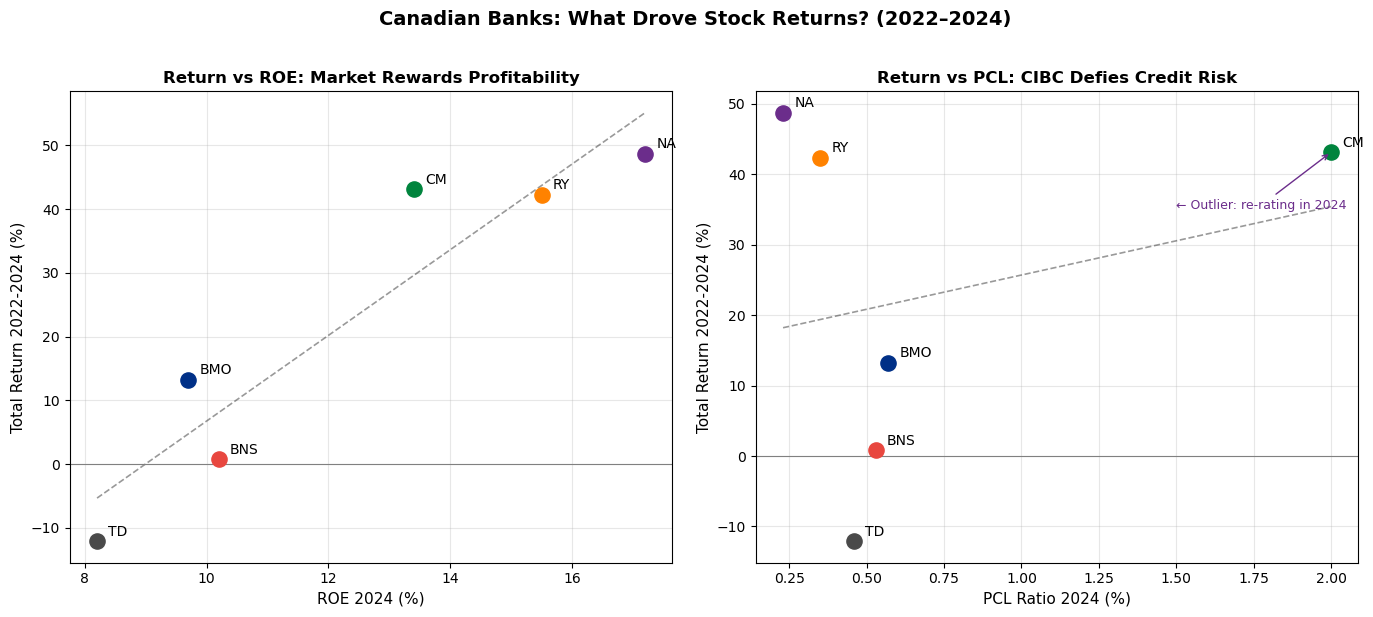

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# ── 数据准备 ──────────────────────────────────────────────────────
# 2022-2024 总回报（用normalized price首尾计算）
total_returns = {}
for ticker in close.columns:
    start = close[ticker].dropna().iloc[0]
    end   = close[ticker].dropna().iloc[-1]
    total_returns[ticker] = round((end - start) / start * 100, 1)

# 2024 ROE & PCL（取最新一年）
roe_2024 = df[df['Year'] == 2024].set_index('Bank')['ROE']
pcl_2024 = df[df['Year'] == 2024].set_index('Bank')['PCL_ratio']

# 对齐 ticker 名（returns用RY.TO，financials用RY.TO——确认一致）
ret_series = pd.Series(total_returns)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
colors = ['#003087','#E8473F','#00843D','#6B2D8B','#FF8200','#4A4A4A']

# ── Chart 1: Return vs ROE ────────────────────────────────────────
ax1 = axes[0]
for i, ticker in enumerate(ret_series.index):
    bank_key = ticker  # e.g. 'RY.TO'
    if bank_key in roe_2024.index:
        x = roe_2024[bank_key]
        y = ret_series[ticker]
        ax1.scatter(x, y, color=colors[i], s=120, zorder=3)
        ax1.annotate(ticker.replace('.TO',''), (x, y),
                     textcoords='offset points', xytext=(8, 4), fontsize=10)

# 回归线
x_vals = [roe_2024[t] for t in ret_series.index if t in roe_2024.index]
y_vals = [ret_series[t] for t in ret_series.index if t in roe_2024.index]
m, b = np.polyfit(x_vals, y_vals, 1)
x_line = np.linspace(min(x_vals), max(x_vals), 100)
ax1.plot(x_line, m * x_line + b, 'k--', alpha=0.4, linewidth=1.2)

ax1.set_xlabel('ROE 2024 (%)', fontsize=11)
ax1.set_ylabel('Total Return 2022-2024 (%)', fontsize=11)
ax1.set_title('Return vs ROE: Market Rewards Profitability', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.axhline(0, color='grey', linewidth=0.8)

# ── Chart 2: Return vs PCL ────────────────────────────────────────
ax2 = axes[1]
for i, ticker in enumerate(ret_series.index):
    bank_key = ticker
    if bank_key in pcl_2024.index:
        x = pcl_2024[bank_key]
        y = ret_series[ticker]
        ax2.scatter(x, y, color=colors[i], s=120, zorder=3)
        ax2.annotate(ticker.replace('.TO',''), (x, y),
                     textcoords='offset points', xytext=(8, 4), fontsize=10)

x_vals2 = [pcl_2024[t] for t in ret_series.index if t in pcl_2024.index]
y_vals2 = [ret_series[t] for t in ret_series.index if t in pcl_2024.index]
m2, b2 = np.polyfit(x_vals2, y_vals2, 1)
x_line2 = np.linspace(min(x_vals2), max(x_vals2), 100)
ax2.plot(x_line2, m2 * x_line2 + b2, 'k--', alpha=0.4, linewidth=1.2)

# CIBC 标注离群点
if 'CM.TO' in pcl_2024.index:
    ax2.annotate('← Outlier: re-rating in 2024',
                 xy=(pcl_2024['CM.TO'], ret_series['CM.TO']),
                 xytext=(pcl_2024['CM.TO'] - 0.5, ret_series['CM.TO'] - 8),
                 fontsize=9, color='#6B2D8B',
                 arrowprops=dict(arrowstyle='->', color='#6B2D8B'))

ax2.set_xlabel('PCL Ratio 2024 (%)', fontsize=11)
ax2.set_ylabel('Total Return 2022-2024 (%)', fontsize=11)
ax2.set_title('Return vs PCL: CIBC Defies Credit Risk', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.axhline(0, color='grey', linewidth=0.8)

plt.suptitle('Canadian Banks: What Drove Stock Returns? (2022–2024)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('return_drivers.png', dpi=150, bbox_inches='tight')
plt.show()

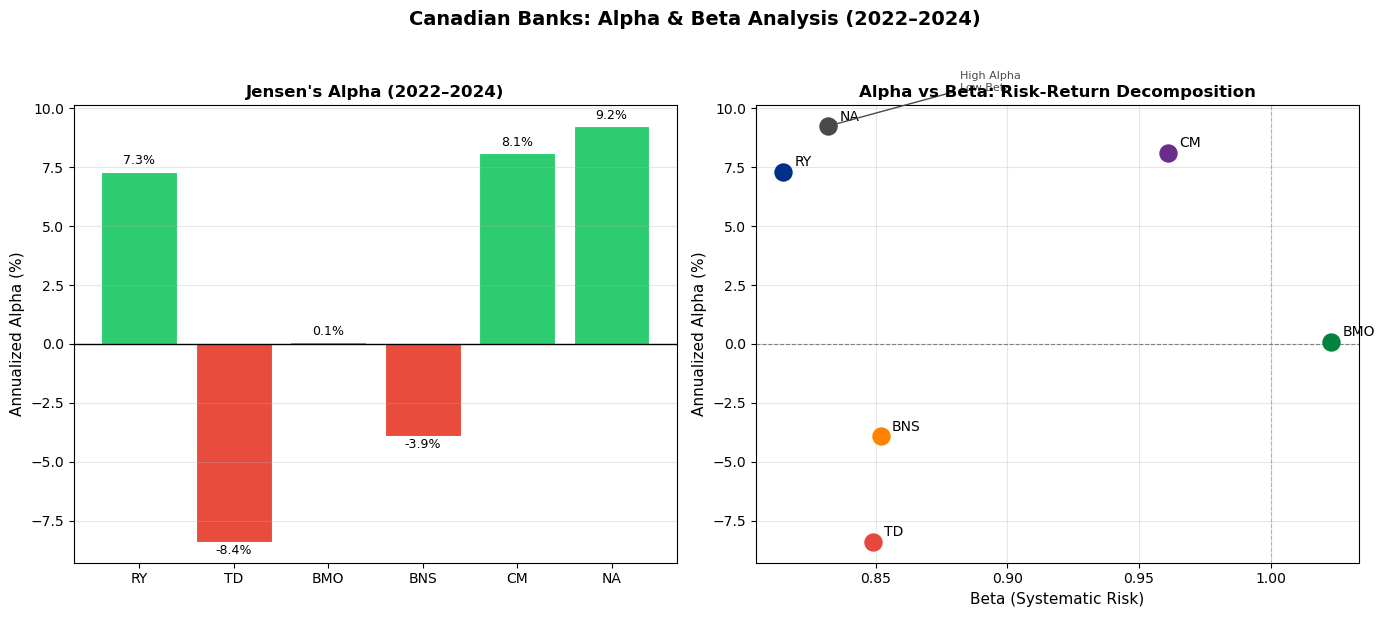

In [16]:
# ── Alpha vs Beta 对比图 ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

tickers = ['RY.TO', 'TD.TO', 'BMO.TO', 'BNS.TO', 'CM.TO', 'NA.TO']
colors_map = {
    'RY.TO':  '#003087',
    'TD.TO':  '#E8473F',
    'BMO.TO': '#00843D',
    'BNS.TO': '#FF8200',
    'CM.TO':  '#6B2D8B',
    'NA.TO':  '#4A4A4A'
}

# ── Chart 1: Alpha 柱状图 ─────────────────────────────────────────
ax1 = axes[0]
alpha_vals = [alpha_df[t] * 100 for t in tickers]
bar_colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in alpha_vals]
labels = [t.replace('.TO','') for t in tickers]
bars = ax1.bar(labels, alpha_vals, color=bar_colors, edgecolor='white', linewidth=0.8)

ax1.axhline(0, color='black', linewidth=1)
ax1.set_ylabel("Annualized Alpha (%)", fontsize=11)
ax1.set_title("Jensen's Alpha (2022–2024)", fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='y')

for bar, val in zip(bars, alpha_vals):
    ax1.text(bar.get_x() + bar.get_width()/2,
             val + (0.3 if val > 0 else -0.5),
             f'{val:.1f}%', ha='center', fontsize=9)

# ── Chart 2: Alpha vs Beta 散点图 ────────────────────────────────
ax2 = axes[1]
for ticker in tickers:
    x = beta_df[ticker]
    y = alpha_df[ticker] * 100
    ax2.scatter(x, y, color=colors_map[ticker], s=150, zorder=3)
    ax2.annotate(ticker.replace('.TO',''), (x, y),
                 textcoords='offset points', xytext=(8, 4), fontsize=10)

ax2.axhline(0, color='grey', linewidth=0.8, linestyle='--')
ax2.axvline(1, color='grey', linewidth=0.8, linestyle='--', alpha=0.5)
ax2.set_xlabel("Beta (Systematic Risk)", fontsize=11)
ax2.set_ylabel("Annualized Alpha (%)", fontsize=11)
ax2.set_title("Alpha vs Beta: Risk-Return Decomposition", fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)

# NA 标注
ax2.annotate('High Alpha\nLow Beta',
             xy=(beta_df['NA.TO'], alpha_df['NA.TO']*100),
             xytext=(beta_df['NA.TO']+0.05, alpha_df['NA.TO']*100+1.5),
             fontsize=8, color='#4A4A4A',
             arrowprops=dict(arrowstyle='->', color='#4A4A4A'))

plt.suptitle("Canadian Banks: Alpha & Beta Analysis (2022–2024)",
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('alpha_beta.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
# ── 读取 BVPS 数据 ─────────────────────────────────────────────────
bvps_df = pd.read_excel(r'C:/Users/lenovo/Desktop/bvps.xlsx')

# ── 取年末股价（10月31日或最近交易日）─────────────────────────────
year_end_prices = {}
for year in [2022, 2023, 2024]:
    date_str = f'{year}-10-31'
    if date_str in close.index:
        year_end_prices[year] = close.loc[date_str]
    else:
        year_end_prices[year] = close.loc[close.index <= date_str].iloc[-1]

price_df = pd.DataFrame(year_end_prices).T
price_df.index.name = 'Year'
price_df = price_df.reset_index()
price_long = price_df.melt(id_vars='Year', var_name='Bank', value_name='Price')

# ── 合并计算 P/B ───────────────────────────────────────────────────
pb_df = bvps_df.merge(price_long, on=['Bank', 'Year'])
pb_df['PB'] = (pb_df['Price'] / pb_df['BVPS']).round(2)
print(pb_df.sort_values(['Bank', 'Year']))

      Bank  Year    BVPS       Price    PB
6   BMO.TO  2022   95.60  107.282631  1.12
7   BMO.TO  2023   95.90   94.029045  0.98
8   BMO.TO  2024  104.40  119.520554  1.14
12  BNS.TO  2022   54.68   53.583660  0.98
13  BNS.TO  2023   56.64   48.723091  0.86
14  BNS.TO  2024   59.14   66.279953  1.12
9    CM.TO  2022   49.95   52.082077  1.04
10   CM.TO  2023   51.56   43.826382  0.85
11   CM.TO  2024   57.08   82.206314  1.44
15   NA.TO  2022   55.24   81.424988  1.47
16   NA.TO  2023   60.40   78.971939  1.31
17   NA.TO  2024   65.75  126.488228  1.92
3    RY.TO  2022   72.85  110.935944  1.52
4    RY.TO  2023   76.92  101.681168  1.32
5    RY.TO  2024   83.46  160.597382  1.92
0    TD.TO  2022   55.00   74.364426  1.35
1    TD.TO  2023   56.56   69.227585  1.22
2    TD.TO  2024   59.59   72.301949  1.21


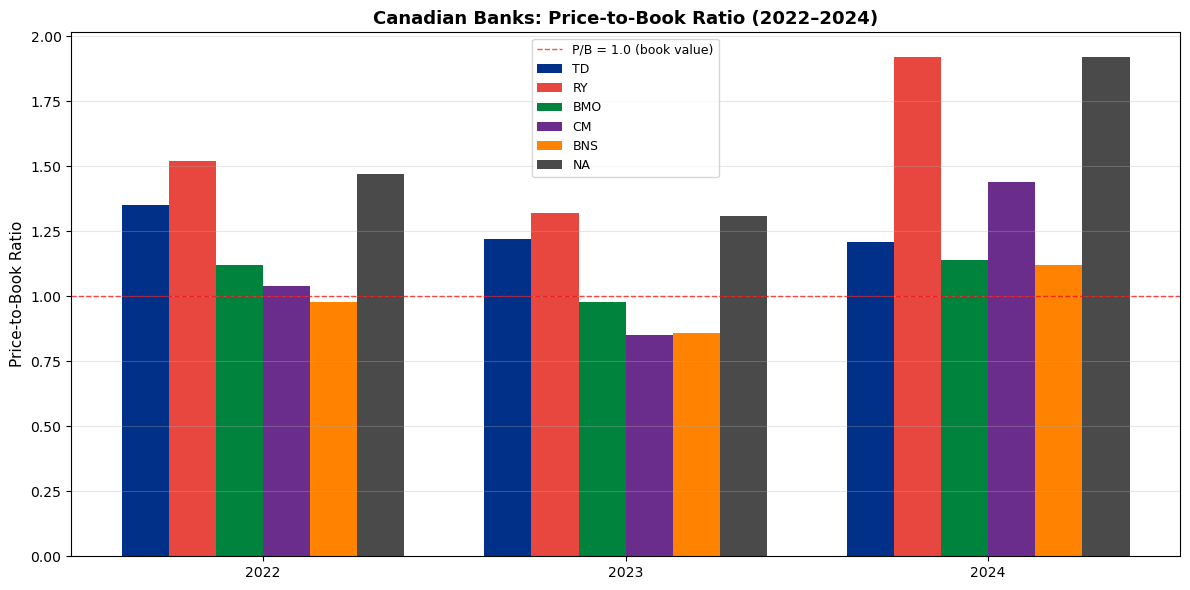

In [13]:
fig, ax = plt.subplots(figsize=(12, 6))

banks = pb_df['Bank'].unique()
colors = ['#003087','#E8473F','#00843D','#6B2D8B','#FF8200','#4A4A4A']
years = [2022, 2023, 2024]
x = np.arange(len(years))
width = 0.13

for i, bank in enumerate(banks):
    vals = pb_df[pb_df['Bank'] == bank].sort_values('Year')['PB'].values
    bars = ax.bar(x + i * width, vals, width, label=bank.replace('.TO',''), color=colors[i])

ax.axhline(1, color='red', linewidth=1, linestyle='--', alpha=0.7, label='P/B = 1.0 (book value)')
ax.set_xticks(x + width * 2.5)
ax.set_xticklabels(['2022', '2023', '2024'])
ax.set_ylabel('Price-to-Book Ratio', fontsize=11)
ax.set_title('Canadian Banks: Price-to-Book Ratio (2022–2024)', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('pb_ratio.png', dpi=150)
plt.show()